# Preprocessing House Sale Prediction

## 1. Import Library

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## 2. Unduh dan Import Dataset

In [52]:
SUMBER = '5054251036_Prima_Surya_Nusantara_Tugas_Praproses_Data.csv'

df = pd.read_csv(SUMBER)

print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

print("5 baris pertama:")
print(df.head())

print("Informasi Tipe Data:")
df.info()

Jumlah baris: 1460
Jumlah kolom: 81
5 baris pertama:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleT

In [53]:
df_bersih = df.drop(columns=["Id"])

print("5 baris pertama:")
print(df_bersih.head())

5 baris pertama:
   MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0          60       RL         65.0     8450   Pave   NaN      Reg   
1          20       RL         80.0     9600   Pave   NaN      Reg   
2          60       RL         68.0    11250   Pave   NaN      IR1   
3          70       RL         60.0     9550   Pave   NaN      IR1   
4          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
0         Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
1         Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
2         Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
3         Lvl    AllPub    Corner  ...        0    NaN   NaN         NaN   
4         Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  SalePrice  
0       0      2    2008        WD        

## 3. Pembersihan Data

In [54]:
print("\nJumlah duplikat:", df_bersih.duplicated().sum())
display(df_bersih[df_bersih.duplicated()])
print("Jumlah baris awal:", len(df_bersih))

df_bersih = df_bersih.drop_duplicates().reset_index(drop=True)

print("Jumlah baris setelah dibersihkan:", len(df_bersih))
print("Sisa duplikat:", df_bersih.duplicated().sum())


Jumlah duplikat: 0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


Jumlah baris awal: 1460
Jumlah baris setelah dibersihkan: 1460
Sisa duplikat: 0


In [55]:
print("Jumlah missing value per kolom:")
print(df_bersih.isna().sum().to_frame("Jumlah Missing"))

print("Jumlah missing cell:", df_bersih.isna().sum().sum())

Jumlah missing value per kolom:
               Jumlah Missing
MSSubClass                  0
MSZoning                    0
LotFrontage               259
LotArea                     0
Street                      0
...                       ...
MoSold                      0
YrSold                      0
SaleType                    0
SaleCondition               0
SalePrice                   0

[80 rows x 1 columns]
Jumlah missing cell: 7829


## 4. Deteksi dan Penanganan Outlier

In [56]:
kolom_numerik = df_bersih.select_dtypes(include="number").columns.tolist()

kolom_kategorik = df_bersih.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

kolom_numerik = [
    kolom for kolom in kolom_numerik
    if kolom not in ["SalePrice", "MSSubClass"]
]

if "MSSubClass" in df_bersih.columns and "MSSubClass" not in kolom_kategorik:
    kolom_kategorik.append("MSSubClass")

# Buat DataFrame terpisah
df_numerik = df_bersih[kolom_numerik].copy()
df_kategorik = df_bersih[kolom_kategorik].copy()

print(f"Jumlah fitur numerik: {len(kolom_numerik)}")
print(kolom_numerik)

print(f"\nJumlah fitur kategorik: {len(kolom_kategorik)}")
print(kolom_kategorik)

Jumlah fitur numerik: 35
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Jumlah fitur kategorik: 44
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', '

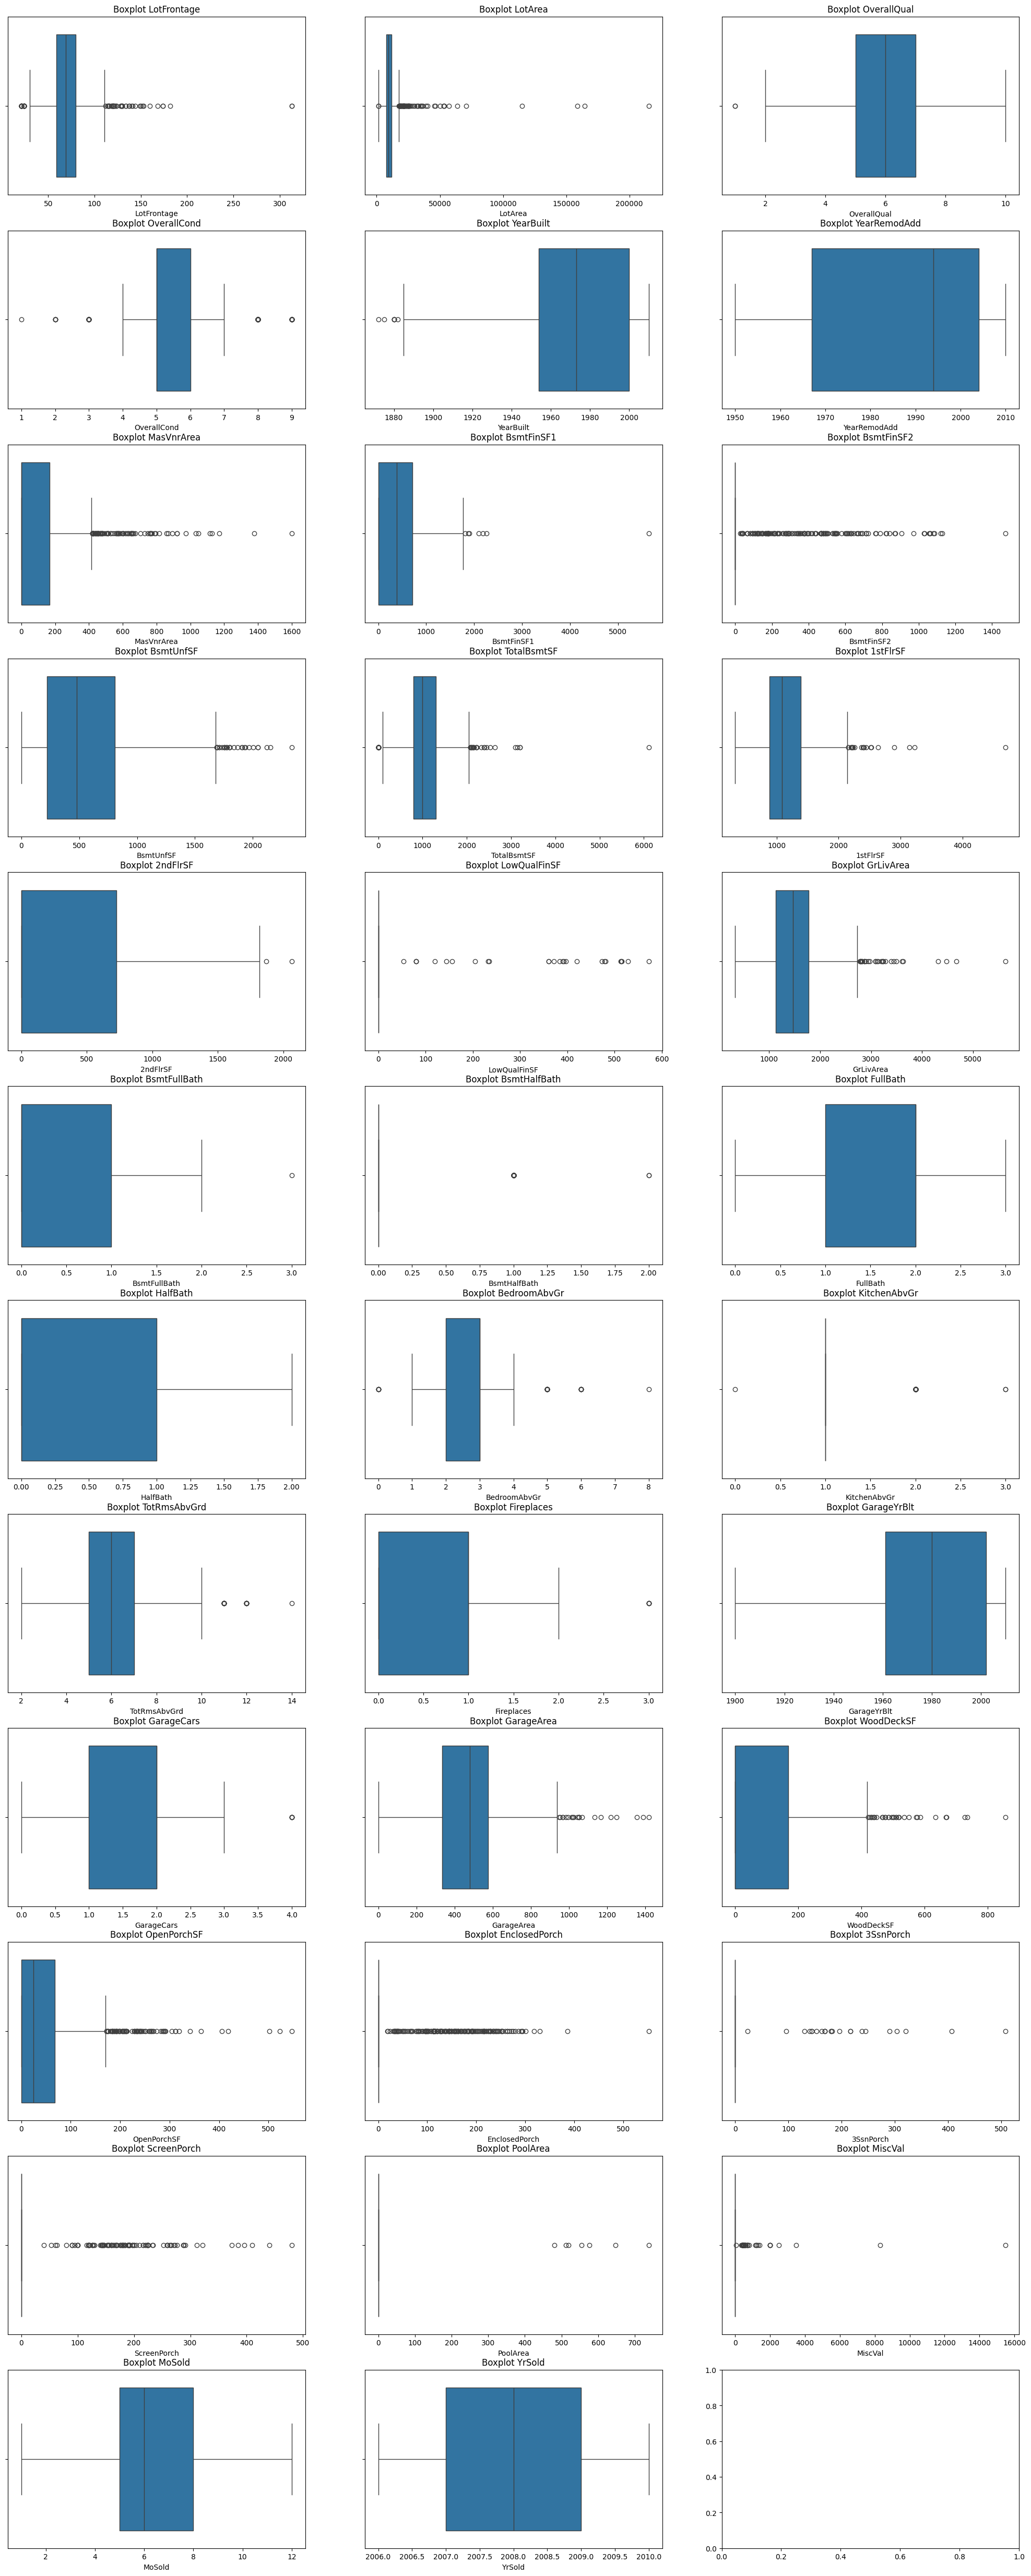

In [57]:
fig, axes = plt.subplots((len(kolom_numerik) + 2) // 3, 3, figsize=(25, 63))

for ax, kolom in zip(axes.flat, kolom_numerik):
    sns.boxplot(x=df_bersih[kolom], ax=ax)
    ax.set_title(f'Boxplot {kolom}')

In [58]:
mask_kandidat = (
    (df_bersih["GrLivArea"] > 4000) &
    (df_bersih["SalePrice"] < 300000)
)

kolom_periksa = [
    "GrLivArea", "OverallQual", "SalePrice", "SaleCondition"
]

if "Id" in df_bersih.columns:
    kolom_periksa = ["Id"] + kolom_periksa

display(df_bersih.loc[mask_kandidat, kolom_periksa])

,GrLivArea,OverallQual,SalePrice,SaleCondition
523,4676,10,184750,Partial
1298,5642,10,160000,Partial


In [59]:
df_tanpa_kandidat = df_bersih.loc[~mask_kandidat].copy()

print("Jumlah data awal:", len(df))
print("Jumlah kandidat:", mask_kandidat.sum())
print("Jumlah setelah dikeluarkan:", len(df_tanpa_kandidat))

Jumlah data awal: 1460
Jumlah kandidat: 2
Jumlah setelah dikeluarkan: 1458


Outlier tidak dihapus karena data tersebut dapat mencerminkan nilai sebenarnya, bukan kesalahan pencatatan. Misalnya dari kolom `BsmntFinSF2` yang memiliki Q1 dan Q3 di nilai 0, di luar itu termasuk outlier. Namun bisa saja hal itu terjadi karena sebagian besar rumah tidak memiliki area basment tipe 2, hanya beberapa rumah saja. Selain itu, ada 2 kandidat baris yang memiliki kualitas rumah yang baik tapi memiliki harga yang sangat rendah. Kandidat tersebut tidak dihilangkan, namun dataset akan dipisah menjadi dataset yang memiliki dan tidak memiliki kandidat tersebut. Penghapusan outlier dapat menghilangkan informasi penting dan membuat dataset kurang mewakili rumah-rumah yang jarang ditemui.

## 5. Transformasi Data

In [60]:
from sklearn.model_selection import train_test_split

X = df_bersih.drop(columns=["SalePrice"]).copy()
y = df_bersih["SalePrice"].copy()

# MSSubClass merupakan kode kategori, bukan besaran numerik.
X["MSSubClass"] = X["MSSubClass"].astype(str)

kolom_numerik = X.select_dtypes(include="number").columns.tolist()
kolom_kategorik = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Ukuran fitur train:", X_train.shape)
print("Ukuran fitur test :", X_test.shape)
print("Jumlah fitur numerik:", len(kolom_numerik))
print("Jumlah fitur kategorik:", len(kolom_kategorik))

Ukuran fitur train: (1168, 79)
Ukuran fitur test : (292, 79)
Jumlah fitur numerik: 35
Jumlah fitur kategorik: 44


In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

proses_numerik = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

proses_kategorik = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Tidak_tercatat"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numerik", proses_numerik, kolom_numerik),
    ("kategorik", proses_kategorik, kolom_kategorik)
])

In [62]:
hasil_train = preprocessor.fit_transform(X_train)

hasil_test = preprocessor.transform(X_test)

nama_fitur = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(
    hasil_train,
    columns=nama_fitur,
    index=X_train.index
)

X_test_final = pd.DataFrame(
    hasil_test,
    columns=nama_fitur,
    index=X_test.index
)

print("Ukuran train setelah preprocessing:", X_train_final.shape)
print("Ukuran test setelah preprocessing :", X_test_final.shape)

print("\nJumlah missing value train:", X_train_final.isna().sum().sum())
print("Jumlah missing value test :", X_test_final.isna().sum().sum())

display(X_train_final.head())

Ukuran train setelah preprocessing: (1168, 315)
Ukuran test setelah preprocessing : (292, 315)

Jumlah missing value train: 0
Jumlah missing value test : 0


,numerik__LotFrontage,numerik__LotArea,numerik__OverallQual,numerik__OverallCond,numerik__YearBuilt,numerik__YearRemodAdd,numerik__MasVnrArea,numerik__BsmtFinSF1,numerik__BsmtFinSF2,numerik__BsmtUnfSF,...,kategorik__SaleType_ConLw,kategorik__SaleType_New,kategorik__SaleType_Oth,kategorik__SaleType_WD,kategorik__SaleCondition_Abnorml,kategorik__SaleCondition_AdjLand,kategorik__SaleCondition_Alloca,kategorik__SaleCondition_Family,kategorik__SaleCondition_Normal,kategorik__SaleCondition_Partial
254,-0.012468,-0.212896,-0.820445,0.372217,-0.455469,-1.346063,-0.597889,1.037269,-0.285504,-0.400282,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1066,-0.502357,-0.265245,-0.088934,1.268609,0.718609,0.439214,-0.597889,-0.971996,-0.285504,0.511920,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
638,-0.146074,-0.177841,-0.820445,1.268609,-1.988293,-1.683818,-0.597889,-0.971996,-0.285504,0.505196,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
799,-0.457822,-0.324474,-0.820445,1.268609,-1.107734,-1.683818,0.861522,0.267995,-0.285504,-0.915776,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
380,-0.903175,-0.529035,-0.820445,0.372217,-1.531707,-1.683818,-0.597889,-0.496920,-0.285504,0.532091,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [63]:
fitur_numerik_final = [
    f"numerik__{kolom}" for kolom in kolom_numerik
]

ringkasan_standardisasi = pd.DataFrame({
    "Mean": X_train_final[fitur_numerik_final].mean(),
    "Standar deviasi": X_train_final[
        fitur_numerik_final
    ].std(ddof=0)
})

print("Pemeriksaan standardisasi pada data train:")
display(ringkasan_standardisasi.round(4))

print("Contoh hasil one-hot encoding:")
display(
    X_train_final.filter(
        like="kategorik__MSZoning_"
    ).head()
)

Pemeriksaan standardisasi pada data train:


,Mean,Standar deviasi
numerik__LotFrontage,-0.0,1.0
numerik__LotArea,0.0,1.0
numerik__OverallQual,-0.0,1.0
numerik__OverallCond,0.0,1.0
numerik__YearBuilt,-0.0,1.0
numerik__YearRemodAdd,0.0,1.0
numerik__MasVnrArea,-0.0,1.0
numerik__BsmtFinSF1,0.0,1.0
numerik__BsmtFinSF2,-0.0,1.0
numerik__BsmtUnfSF,0.0,1.0


Contoh hasil one-hot encoding:


,kategorik__MSZoning_C (all),kategorik__MSZoning_FV,kategorik__MSZoning_RH,kategorik__MSZoning_RL,kategorik__MSZoning_RM
254,0.0,0.0,0.0,1.0,0.0
1066,0.0,0.0,0.0,1.0,0.0
638,0.0,0.0,0.0,1.0,0.0
799,0.0,0.0,0.0,1.0,0.0
380,0.0,0.0,0.0,1.0,0.0


## 6. Reduksi Dimensi

In [64]:
fitur_numerik_final = [
    kolom for kolom in X_train_final.columns
    if kolom.startswith("numerik__")
]

korelasi = X_train_final[fitur_numerik_final].corr()

fitur_numerik_final = [
    kolom for kolom in X_train_final.columns
    if kolom.startswith("numerik__")
]

korelasi = X_train_final[fitur_numerik_final].corr()

ambang = 0.90
pasangan = []

for i in range(len(korelasi.columns)):
    for j in range(i + 1, len(korelasi.columns)):
        nilai = korelasi.iloc[i, j]

        if pd.notna(nilai) and abs(nilai) > ambang:
            pasangan.append({
                "Atribut 1": korelasi.columns[i],
                "Atribut 2": korelasi.columns[j],
                "Korelasi": nilai,
                "|Korelasi|": abs(nilai)
            })

pasangan_korelasi = pd.DataFrame(
    pasangan,
    columns=["Atribut 1", "Atribut 2", "Korelasi", "|Korelasi|"]
).sort_values("|Korelasi|", ascending=False)

print("Pasangan atribut dengan |korelasi| > 0.90:")
display(pasangan_korelasi)

Pasangan atribut dengan |korelasi| > 0.90:


,Atribut 1,Atribut 2,Korelasi,|Korelasi|


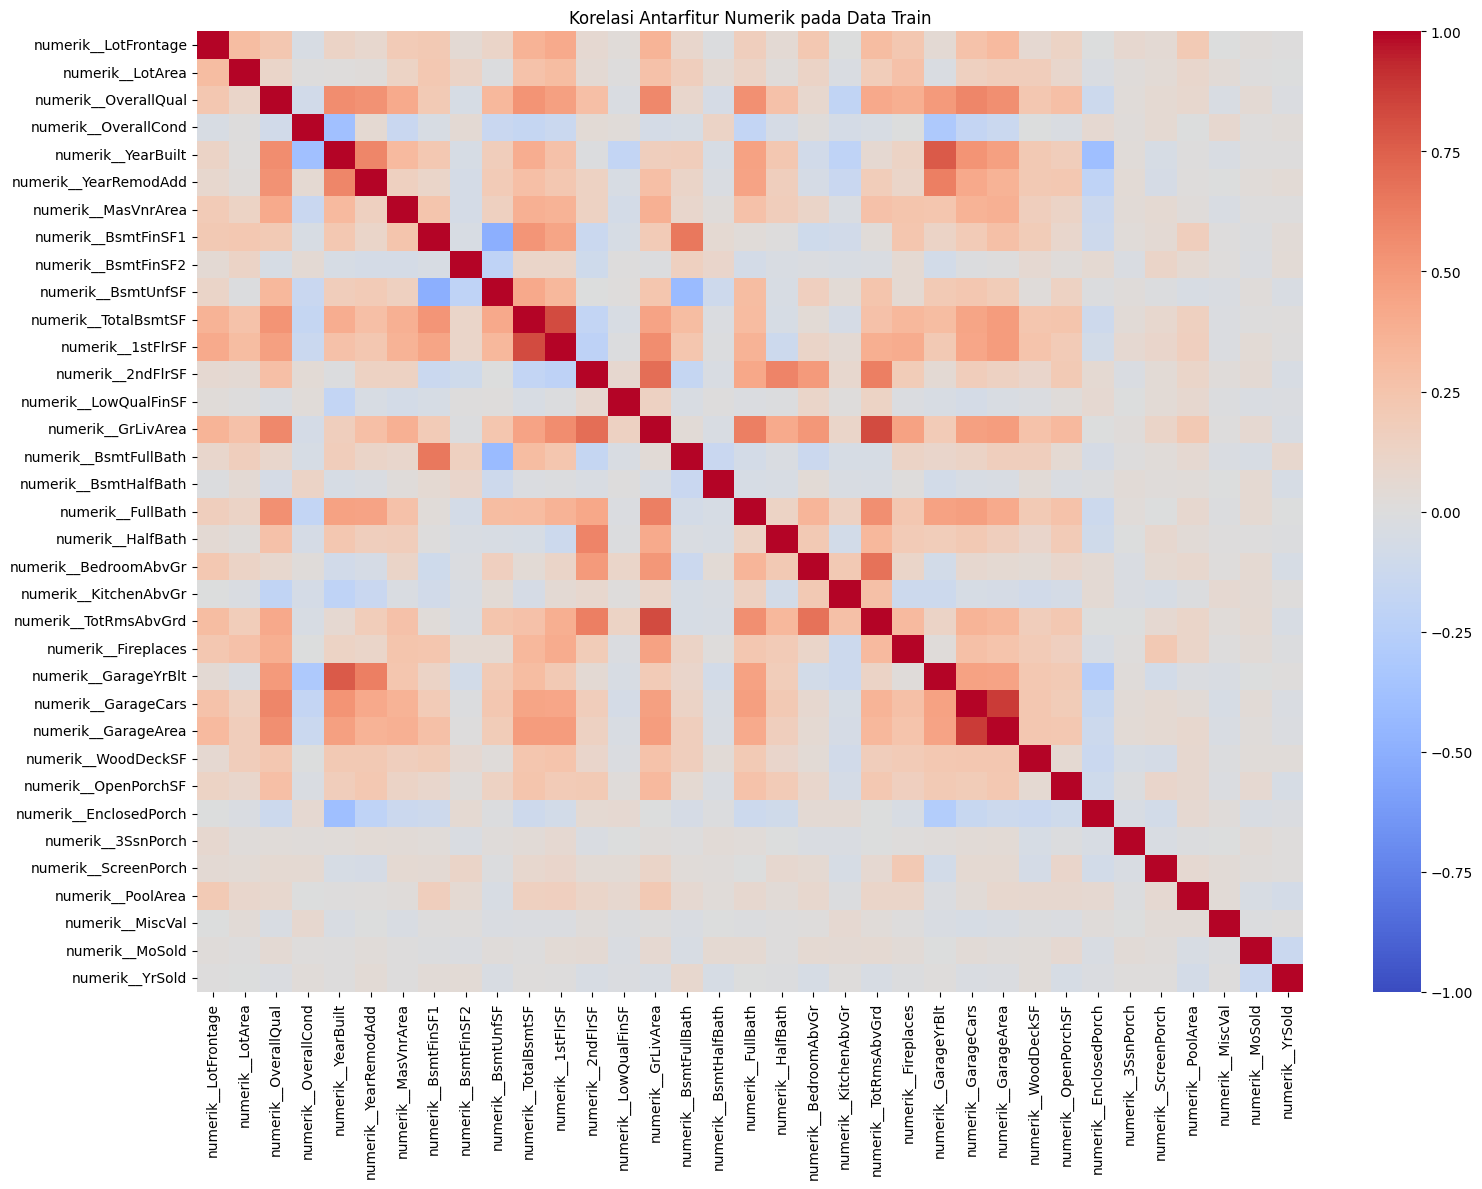

In [65]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    korelasi,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Korelasi Antarfitur Numerik pada Data Train")
plt.tight_layout()
plt.show()

In [66]:
korelasi_target = (
    X_train_final[fitur_numerik_final]
    .corrwith(y_train)
    .abs()
    .fillna(0)
    .sort_values(ascending=False)
)

fitur_dipertahankan = []
catatan_hapus = []

for fitur in korelasi_target.index:
    fitur_serupa = [
        fitur_lama
        for fitur_lama in fitur_dipertahankan
        if abs(korelasi.loc[fitur, fitur_lama]) > ambang
    ]

    if fitur_serupa:
        pembanding = max(
            fitur_serupa,
            key=lambda f: abs(korelasi.loc[fitur, f])
        )

        catatan_hapus.append({
            "Dihapus": fitur,
            "Dipertahankan": pembanding,
            "|Korelasi antarfitur|":
                abs(korelasi.loc[fitur, pembanding]),
            "|Korelasi target fitur dihapus|":
                korelasi_target[fitur],
            "|Korelasi target fitur dipertahankan|":
                korelasi_target[pembanding]
        })
    else:
        fitur_dipertahankan.append(fitur)

laporan_hapus = pd.DataFrame(
    catatan_hapus,
    columns=[
        "Dihapus",
        "Dipertahankan",
        "|Korelasi antarfitur|",
        "|Korelasi target fitur dihapus|",
        "|Korelasi target fitur dipertahankan|"
    ]
)

kolom_dihapus = laporan_hapus["Dihapus"].tolist()

X_train_seleksi = X_train_final.drop(columns=kolom_dihapus)
X_test_seleksi = X_test_final.drop(columns=kolom_dihapus)

display(laporan_hapus)

print("Jumlah fitur sebelum seleksi:", X_train_final.shape[1])
print("Jumlah fitur yang dihapus:", len(kolom_dihapus))
print("Jumlah fitur setelah seleksi:", X_train_seleksi.shape[1])

,Dihapus,Dipertahankan,|Korelasi antarfitur|,|Korelasi target fitur dihapus|,|Korelasi target fitur dipertahankan|


Jumlah fitur sebelum seleksi: 315
Jumlah fitur yang dihapus: 0
Jumlah fitur setelah seleksi: 315


In [67]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

hasil_pca_train = pca.fit_transform(X_train_seleksi)

hasil_pca_test = pca.transform(X_test_seleksi)

nama_pc = [
    f"PC{i + 1}"
    for i in range(pca.n_components_)
]

X_train_pca = pd.DataFrame(
    hasil_pca_train,
    columns=nama_pc,
    index=X_train_seleksi.index
)

X_test_pca = pd.DataFrame(
    hasil_pca_test,
    columns=nama_pc,
    index=X_test_seleksi.index
)

print("Jumlah fitur sebelum PCA:", X_train_seleksi.shape[1])
print("Jumlah komponen setelah PCA:", pca.n_components_)
print(
    "Total varians yang dipertahankan:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

display(X_train_pca.head())

Jumlah fitur sebelum PCA: 315
Jumlah komponen setelah PCA: 82
Total varians yang dipertahankan: 95.11%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC73,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82
254,-2.529878,-1.727127,1.813060,-0.126230,0.845382,-0.112558,0.039097,0.700275,1.077882,0.634219,...,-0.415339,-0.209742,0.101978,0.261383,-0.324968,-0.140136,0.051893,-0.075235,-0.069476,0.146164
1066,0.669476,1.473946,-2.508961,-0.941330,-1.072488,0.171261,0.133501,1.201234,0.570507,0.614175,...,0.020516,-0.239516,0.052093,-0.328784,-0.017293,0.119870,-0.010817,0.148964,0.140167,0.036082
638,-5.238307,-0.217732,-0.321309,1.063343,-0.629853,-1.543048,-0.084975,0.546875,0.494626,1.525396,...,0.014848,-0.068356,-0.189164,0.099578,-0.401418,0.315064,-0.982683,-0.372170,-0.130466,-0.004880
799,-2.314371,2.365059,1.889683,-1.635558,-0.753448,-0.862125,-2.572434,-0.863157,0.831838,0.145350,...,-0.063116,-0.040138,0.068835,0.296828,0.566376,-0.272030,0.313888,-0.610120,-0.271336,-0.108827
380,-3.150015,2.355073,0.801351,1.192516,-0.593442,-1.485813,-1.921419,0.695649,1.474185,-0.407407,...,-0.595105,-0.321099,0.089953,0.110445,0.232771,0.069557,0.071083,-0.038473,-0.417910,-0.001016


,Komponen,Varians dijelaskan (%),Varians kumulatif (%)
0,PC1,16.655298,16.655298
1,PC2,7.353864,24.009162
2,PC3,6.371760,30.380923
3,PC4,4.271264,34.652186
4,PC5,3.059066,37.711252
...,...,...,...
77,PC78,0.146295,94.573382
78,PC79,0.142708,94.716090
79,PC80,0.134809,94.850899
80,PC81,0.132482,94.983382


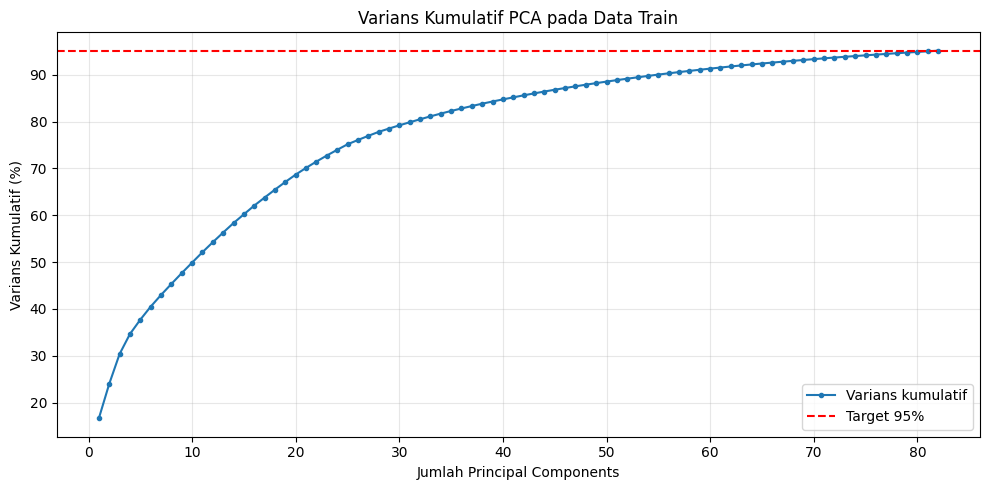

In [68]:
ringkasan_pca = pd.DataFrame({
    "Komponen": nama_pc,
    "Varians dijelaskan (%)":
        pca.explained_variance_ratio_ * 100,
    "Varians kumulatif (%)":
        np.cumsum(pca.explained_variance_ratio_) * 100
})

display(ringkasan_pca)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, pca.n_components_ + 1),
    ringkasan_pca["Varians kumulatif (%)"],
    marker=".",
    label="Varians kumulatif"
)

plt.axhline(
    y=95,
    color="red",
    linestyle="--",
    label="Target 95%"
)

plt.xlabel("Jumlah Principal Components")
plt.ylabel("Varians Kumulatif (%)")
plt.title("Varians Kumulatif PCA pada Data Train")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
train_bersih = X_train_final.copy()
train_bersih["SalePrice"] = y_train

test_bersih = X_test_final.copy()
test_bersih["SalePrice"] = y_test

train_bersih.to_csv("train_bersih.csv", index=False)
test_bersih.to_csv("test_bersih.csv", index=False)

print("Data hasil preprocessing berhasil disimpan.")

Data hasil preprocessing berhasil disimpan.
